Iterative workflow: 
  start
    
 generate

 evaluate - - -> if approved - > end 
      |        else optimize --
     |                        |
    |--------------------------


In [9]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel,Field
from langchain_core.messages import SystemMessage, HumanMessage
import operator

In [18]:
llm1 = HuggingFaceEndpoint(
    repo_id="meta-llama/Meta-Llama-3-8B-Instruct",  # provider-backed
    task="text-generation",
    temperature=0.7,
)

llm2=HuggingFaceEndpoint(
    repo_id="deepseek-ai/DeepSeek-V3",
    task="text-generation",
    temperature=0.3,
)

llm3=HuggingFaceEndpoint(
    repo_id="meta-llama/Meta-Llama-3-8B-Instruct",
    task="text-generation",
    temperature=0.7,
)


GeneratorModel = ChatHuggingFace(llm=llm1)
OptimizerModel=ChatHuggingFace(llm=llm3)
EvalutorModel=ChatHuggingFace(llm=llm2)

In [5]:
class TweetState(TypedDict):
    topic:str # to generate a tweet 
    tweet:str
    evaluation:Literal["approved","needs_improvement"]
    feedback:str # by evaluator
    iterations:int # no fo iteration
    max_iterations:int=5 # to close workflow

In [6]:
class TweetEvaluationSchema(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(description="The overall evaluation result: 'approved' if the tweet meets all criteria, 'needs_improvement' if it requires changes.")
    feedback: str = Field(description="A brief explanation of the tweet's strengths and weaknesses, including specific suggestions for improvement if needed.")

In [7]:
def generate_tweet(state=TweetState):
    prompt = [
        SystemMessage(content="You are a funny, clever, and responsible Twitter/X influencer. Write tweets with personality and readability."),
        HumanMessage(content=f"""
Generate a single tweet to the point, based on this topic: "{state['topic']}".

Requirements:
- Must be 1 tweet only (no thread)
- To the point tweet no extra comments
- Max 200 characters (including hashtags)
- Do NOT use question-answer format
- Use observational humor, irony, sarcasm or cultural reference
- Include a concise punchline and relatable voice
- Use simple, day to day english
- Avoid offensive language and maintain platform safe tone

Additional:
- Include up to 2 relevant hashtags
- Do not describe user requirements in the tweet
- Do not include mentions (@username)
- Use plain text only (no code blocks)
""")
    ]

    response=GeneratorModel.invoke(prompt)
    print("generate",response.content)
    return {"tweet":response.content}

In [11]:
print(generate_tweet({"topic":"Pakistan's Economy"}))

generate Pakistan's economy is
{'tweet': "Pakistan's economy is"}


In [12]:

def evaluate_tweet(state:TweetState):
    evaluation_parser = PydanticOutputParser(pydantic_object=TweetEvaluationSchema)
    prompt=[
        SystemMessage(content="You are a ruthless, no-nonsense Twitter critic. Evaluate tweets strictly on humor, originality, versatility, and tweet format. Be direct and critical."),
        HumanMessage(content=f"""
Evaluate the following tweet on the topic: "{state['topic']}"

Tweet:
"{state['tweet']}"

Criteria:
- Humor: Is it funny? (observational, ironic, sarcastic, or meme-like?)
- Originality: Is it unique or cliché?
- Versatility: Does it work well on Twitter? (engaging, shareable, timely?)
- Format: Proper length (<200 chars), no Q&A format, includes hashtags? (not a setup-punchline joke, not a Q&A joke, and under 200 characters)
- Do not include any user requirement repetation in the original tweet (eg.,The user wants a single tweet about "Pakistan\'s Economy" with specific requirements:\n- 1 tweet only (no th..... )
Auto-reject if:
- include any explanation or comments or user requirements in the original tweet (e.g., "user given this topic ..., user wants ....")
- It's written in question-answer format (e.g., "What happens when ...")
- It exceeds 200 characters
- It reads like a traditional setup-punchline joke
- Don't end with generic, throwaway, or deflating lines that weaken humor (e.g., "masterpiece of anti-humor")

output only valid JSON matching TweetEvaluationSchema
{evaluation_parser.get_format_instructions()}
""")
    ]
    response = EvalutorModel.invoke(prompt)
    print("evaluate",response.content)
    parsed_output = evaluation_parser.parse(response.content)
    return {"evaluation": parsed_output.evaluation, "feedback": parsed_output.feedback}


In [13]:
tweet='The user wants a single tweet about "Pakistan\'s Economy" with specific requirements:\n- 1 tweet only (no thread)\n- To the point, no extra comments\n- Max 200 characters\n- No question-answer format\n- Observational humor, irony, sarcasm or cultural reference\n- Concise punchline, relatable voice\n- Simple, day-to-day English\n- No offensive language, platform safe\n- Up to 2 relevant hashtags\n- No mentions\n- Plain text only\n\nLet me craft something that\'s witty, observational, and relatable about Pakistan\'s economy without being offensive. I should use humor/irony but keep it light and not mean-spirited.\n\nPossible angles:\n- The cycle of economic ups and downs\n- The "tension" between expectations and reality\n- The resilience of people despite economic challenges\n- Common relatable experiences like price increases, currency value\n\nLet me try a few:\n\n1. "Pakistan economy be like: one day we\'re rising, next day we\'re looking for the remote to change the channel. 🇵🇰 #Economy #Pakistan"\n\n2. "Rupee does a magic trick - disappears right when you need it. But hey, we Pakistanis have mastered the art of budget magic! 💫 #PakistanEconomy #DesiLife"\n\n3. "One minute: \'Economy is booming!\' Next minute: \'Why is chai getting expensive?\' Welcome to the Pakistani economic rollercoaster - hold tight! 🎢 #Pakistan #Economy"\n\nLet me check character counts and make them punchier:\n\nOption 1: "Pakistan economy be like: one day we\'re rising, next day we\'re looking for the remote to change the channel. 🇵🇰 #Economy #Pakistan" - 116 characters - good!\n\nOption 2: "Rupee plays hide and seek - disappears right when you need it. But we\'ve mastered the art of budget magic! 💫 #PakistanEconomy #DesiLife" - 132 characters - good!\n\n\nOption 3: "One minute: \'Economy is booming!\' Next minute: \'Why is chai getting expensive?\' Welcome to the Pakistani economic rollercoaster - hold tight! 🎢 #Pakistan #Economy" - 148 characters - good!\n\nI\'ll select the third option as it captures the economic波动 with a humorous, relatable tone. The tweet highlights the unpredictable nature of Pakistan\'s economy through a light-hearted lens, connecting everyday experiences like chai prices to broader economic realities. It\'s witty, safe, and resonates with'
print(evaluate_tweet({"topic":"Pakistan's Economy",'tweet':tweet}))

evaluate ```json
{
  "evaluation": "approved",
  "feedback": "The tweet effectively uses observational humor to comment on Pakistan's economy, capturing the unpredictability with a light-hearted tone. It's relatable, concise, under 200 characters, and includes relevant hashtags. The humor is safe and platform-appropriate, making it shareable and engaging for Twitter audiences."
}
```
{'evaluation': 'approved', 'feedback': "The tweet effectively uses observational humor to comment on Pakistan's economy, capturing the unpredictability with a light-hearted tone. It's relatable, concise, under 200 characters, and includes relevant hashtags. The humor is safe and platform-appropriate, making it shareable and engaging for Twitter audiences."}


In [14]:
def optimize_tweet(state: TweetState):
    prompt = [
        SystemMessage(content="You are a skilled tweet optimizer. Improve tweets based on feedback while maintaining humor and Twitter format."),
        HumanMessage(content=f"""
Optimize the following tweet based on the evaluation feedback.

Original Tweet:
"{state['tweet']}"

Topic: "{state['topic']}"

Feedback: "{state['feedback']}"

Requirements:
- Keep it under 200 characters
- Maintain humor, originality, and engagement
- Address the feedback points directly
- Do not use Q&A format
- Include up to 2 relevant hashtags
- Output only the improved tweet text, no explanations
""")
    ]
    response = OptimizerModel.invoke(prompt)
    print("potimizer",response.content)
    improved_tweet = response.content.strip()
    return {"tweet": improved_tweet, "iterations": state.get('iterations', 0) + 1}

In [15]:
def check_evaluation(state: TweetState) -> Literal["approved", "optimize_tweet"]:
    if state['evaluation'] == 'approved':
        return "approved"
    elif state.get('iterations', 0) >= state['max_iterations']:
        return "approved"  # Force approval after max iterations
    else:
        return "need_improvement"

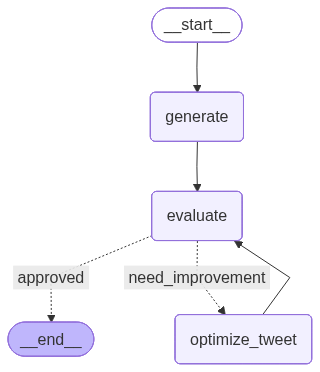

In [16]:
graph=StateGraph(TweetState)

# create nodes
graph.add_node("generate",generate_tweet)
graph.add_node("evaluate",evaluate_tweet)
graph.add_node("optimize_tweet",optimize_tweet)

# create edges
graph.add_edge(START, "generate")
graph.add_edge("generate", "evaluate")
graph.add_conditional_edges("evaluate", check_evaluation, {"approved": END, "need_improvement": "optimize_tweet"})
graph.add_edge("optimize_tweet", "evaluate")
graph.compile()

In [19]:
workflow=graph.compile()

final_state = workflow.invoke({'topic': "Trump and its Make USA Strong", 'max_iterations': 5})

import json
print("Final State:")
print(json.dumps(dict(final_state), indent=4))

generate "Just watched a documentary on ancient civilizations. Guess you could say 'Make Rome Great Again' was a more effective strategy than 'Make America Great Again'. Priorities, people! #MAGAorNotGAI?"
evaluate ```json
{
  "evaluation": "approved",
  "feedback": "The tweet scores well on humor with its sarcastic twist on the 'MAGA' slogan, comparing it to ancient Rome. It's original, avoiding clichés by blending historical commentary with modern political satire. The format is ideal for Twitter: concise, under 200 characters, and includes a relevant hashtag. It's versatile, likely to engage and be shared due to its timely and ironic nature."
}
```
Final State:
{
    "topic": "Trump and its Make USA Strong",
    "tweet": "\"Just watched a documentary on ancient civilizations. Guess you could say 'Make Rome Great Again' was a more effective strategy than 'Make America Great Again'. Priorities, people! #MAGAorNotGAI?\"",
    "evaluation": "approved",
    "feedback": "The tweet scores 